In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

In [6]:

# ==== CONFIG ====
CSV_PATH = "/Users/lucasastore/Library/Mobile Documents/com~apple~CloudDocs/Doutorado/DCC UFMG/Neural Network Cellular Automata/st_gnca/st_gnca/data/PEMS08/data.csv"       # path to your dataset
OUTPUT_PATH = "/Users/lucasastore/Library/Mobile Documents/com~apple~CloudDocs/Doutorado/DCC UFMG/Neural Network Cellular Automata/st_gnca/st_gnca/data/PEMS08/data-preprocessed.csv"
TIME_COL = "timestamp"          # adjust if your column name differs

# ==== LOAD ====
df = pd.read_csv(CSV_PATH)

# Ensure timestamp is in datetime format
df[TIME_COL] = pd.to_datetime(df[TIME_COL], dayfirst=True, format="%Y-%m-%d %H:%M:%S")

# Sort by time (important for temporal models)
df = df.sort_values(by=TIME_COL).reset_index(drop=True)


In [7]:

# ==== HANDLE MISSING VALUES ====
df = df.interpolate(method="linear", limit_direction="both")


In [8]:

# ==== OUTLIER DETECTION ====
# Option A: Z-score method (remove values with |z| > 3)
def remove_outliers_zscore(df, cols, threshold=3):
    clean_df = df.copy()
    for col in cols:
        z_scores = (df[col] - df[col].mean()) / df[col].std()
        clean_df.loc[np.abs(z_scores) > threshold, col] = np.nan
    return clean_df


In [18]:

# Option B: IQR method (outside 1.5 * IQR considered outlier)
def remove_outliers_iqr(df, cols, factor=1.5):
    clean_df = df.copy()
    for col in cols:
        Q1, Q3 = df[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lower, upper = Q1 - factor * IQR, Q3 + factor * IQR
        clean_df.loc[(df[col] < lower) | (df[col] > upper), col] = np.nan
    return clean_df


In [9]:

# Apply outlier removal
sensor_cols = df.columns.drop(TIME_COL)
df = remove_outliers_zscore(df, sensor_cols, threshold=3)

# Re-interpolate after removing outliers
df = df.interpolate(method="linear", limit_direction="both")


In [10]:
df[sensor_cols] = df[sensor_cols].round(2)

# ==== SAVE ====
df.to_csv(OUTPUT_PATH, index=False)

print(f"✅ Preprocessing done! Saved at {OUTPUT_PATH}")


✅ Preprocessing done! Saved at /Users/lucasastore/Library/Mobile Documents/com~apple~CloudDocs/Doutorado/DCC UFMG/Neural Network Cellular Automata/st_gnca/st_gnca/data/PEMS08/data-preprocessed.csv


In [1]:
import zipfile
import os

ZIP_PATH = "/Users/lucasastore/Library/Mobile Documents/com~apple~CloudDocs/Doutorado/DCC UFMG/Neural Network Cellular Automata/st_gnca/st_gnca/data/METR-LA/METR-LA.h5.zip"
EXTRACT_DIR = "/Users/lucasastore/Library/Mobile Documents/com~apple~CloudDocs/Doutorado/DCC UFMG/Neural Network Cellular Automata/st_gnca/st_gnca/data/METR-LA/"

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Extracted files:", os.listdir(EXTRACT_DIR))


Extracted files: ['METR-LA.h5.zip', 'METR-LA.h5']


In [6]:
import pandas as pd

# Load your graph CSV
df = pd.read_csv("/Users/lucasastore/Library/Mobile Documents/com~apple~CloudDocs/Doutorado/DCC UFMG/Neural Network Cellular Automata/st_gnca/st_gnca/data/PEMS08/edges_cleaned.csv")  # columns: source, target, weight

# Min-Max normalization
df["weight"] = (df["weight"] - df["weight"].min()) / (df["weight"].max() - df["weight"].min())
df["weight"] = df["weight"].round(4)


# Optional: replace the original weight
# df["weight"] = df["weight_normalized"]

# Save normalized graph
df.to_csv("/Users/lucasastore/Library/Mobile Documents/com~apple~CloudDocs/Doutorado/DCC UFMG/Neural Network Cellular Automata/st_gnca/st_gnca/data/PEMS08/edges_normalized.csv", index=False)
print("✅ Normalized weights saved!")


✅ Normalized weights saved!


In [1]:
import pandas as pd

# Read the CSV
df = pd.read_csv("/Users/lucasastore/Library/Mobile Documents/com~apple~CloudDocs/Doutorado/DCC UFMG/Neural Network Cellular Automata/st_gnca/st_gnca/data/PEMS08/edges.csv")

# Drop exact duplicate rows
df_cleaned = df.drop_duplicates()

# (Optional) Reset index
df_cleaned = df_cleaned.reset_index(drop=True)

# Save back to CSV
df_cleaned.to_csv("/Users/lucasastore/Library/Mobile Documents/com~apple~CloudDocs/Doutorado/DCC UFMG/Neural Network Cellular Automata/st_gnca/st_gnca/data/PEMS08/edges_cleaned.csv", index=False)

print("Removed duplicates. Saved as edges_cleaned.csv")


Removed duplicates. Saved as edges_cleaned.csv


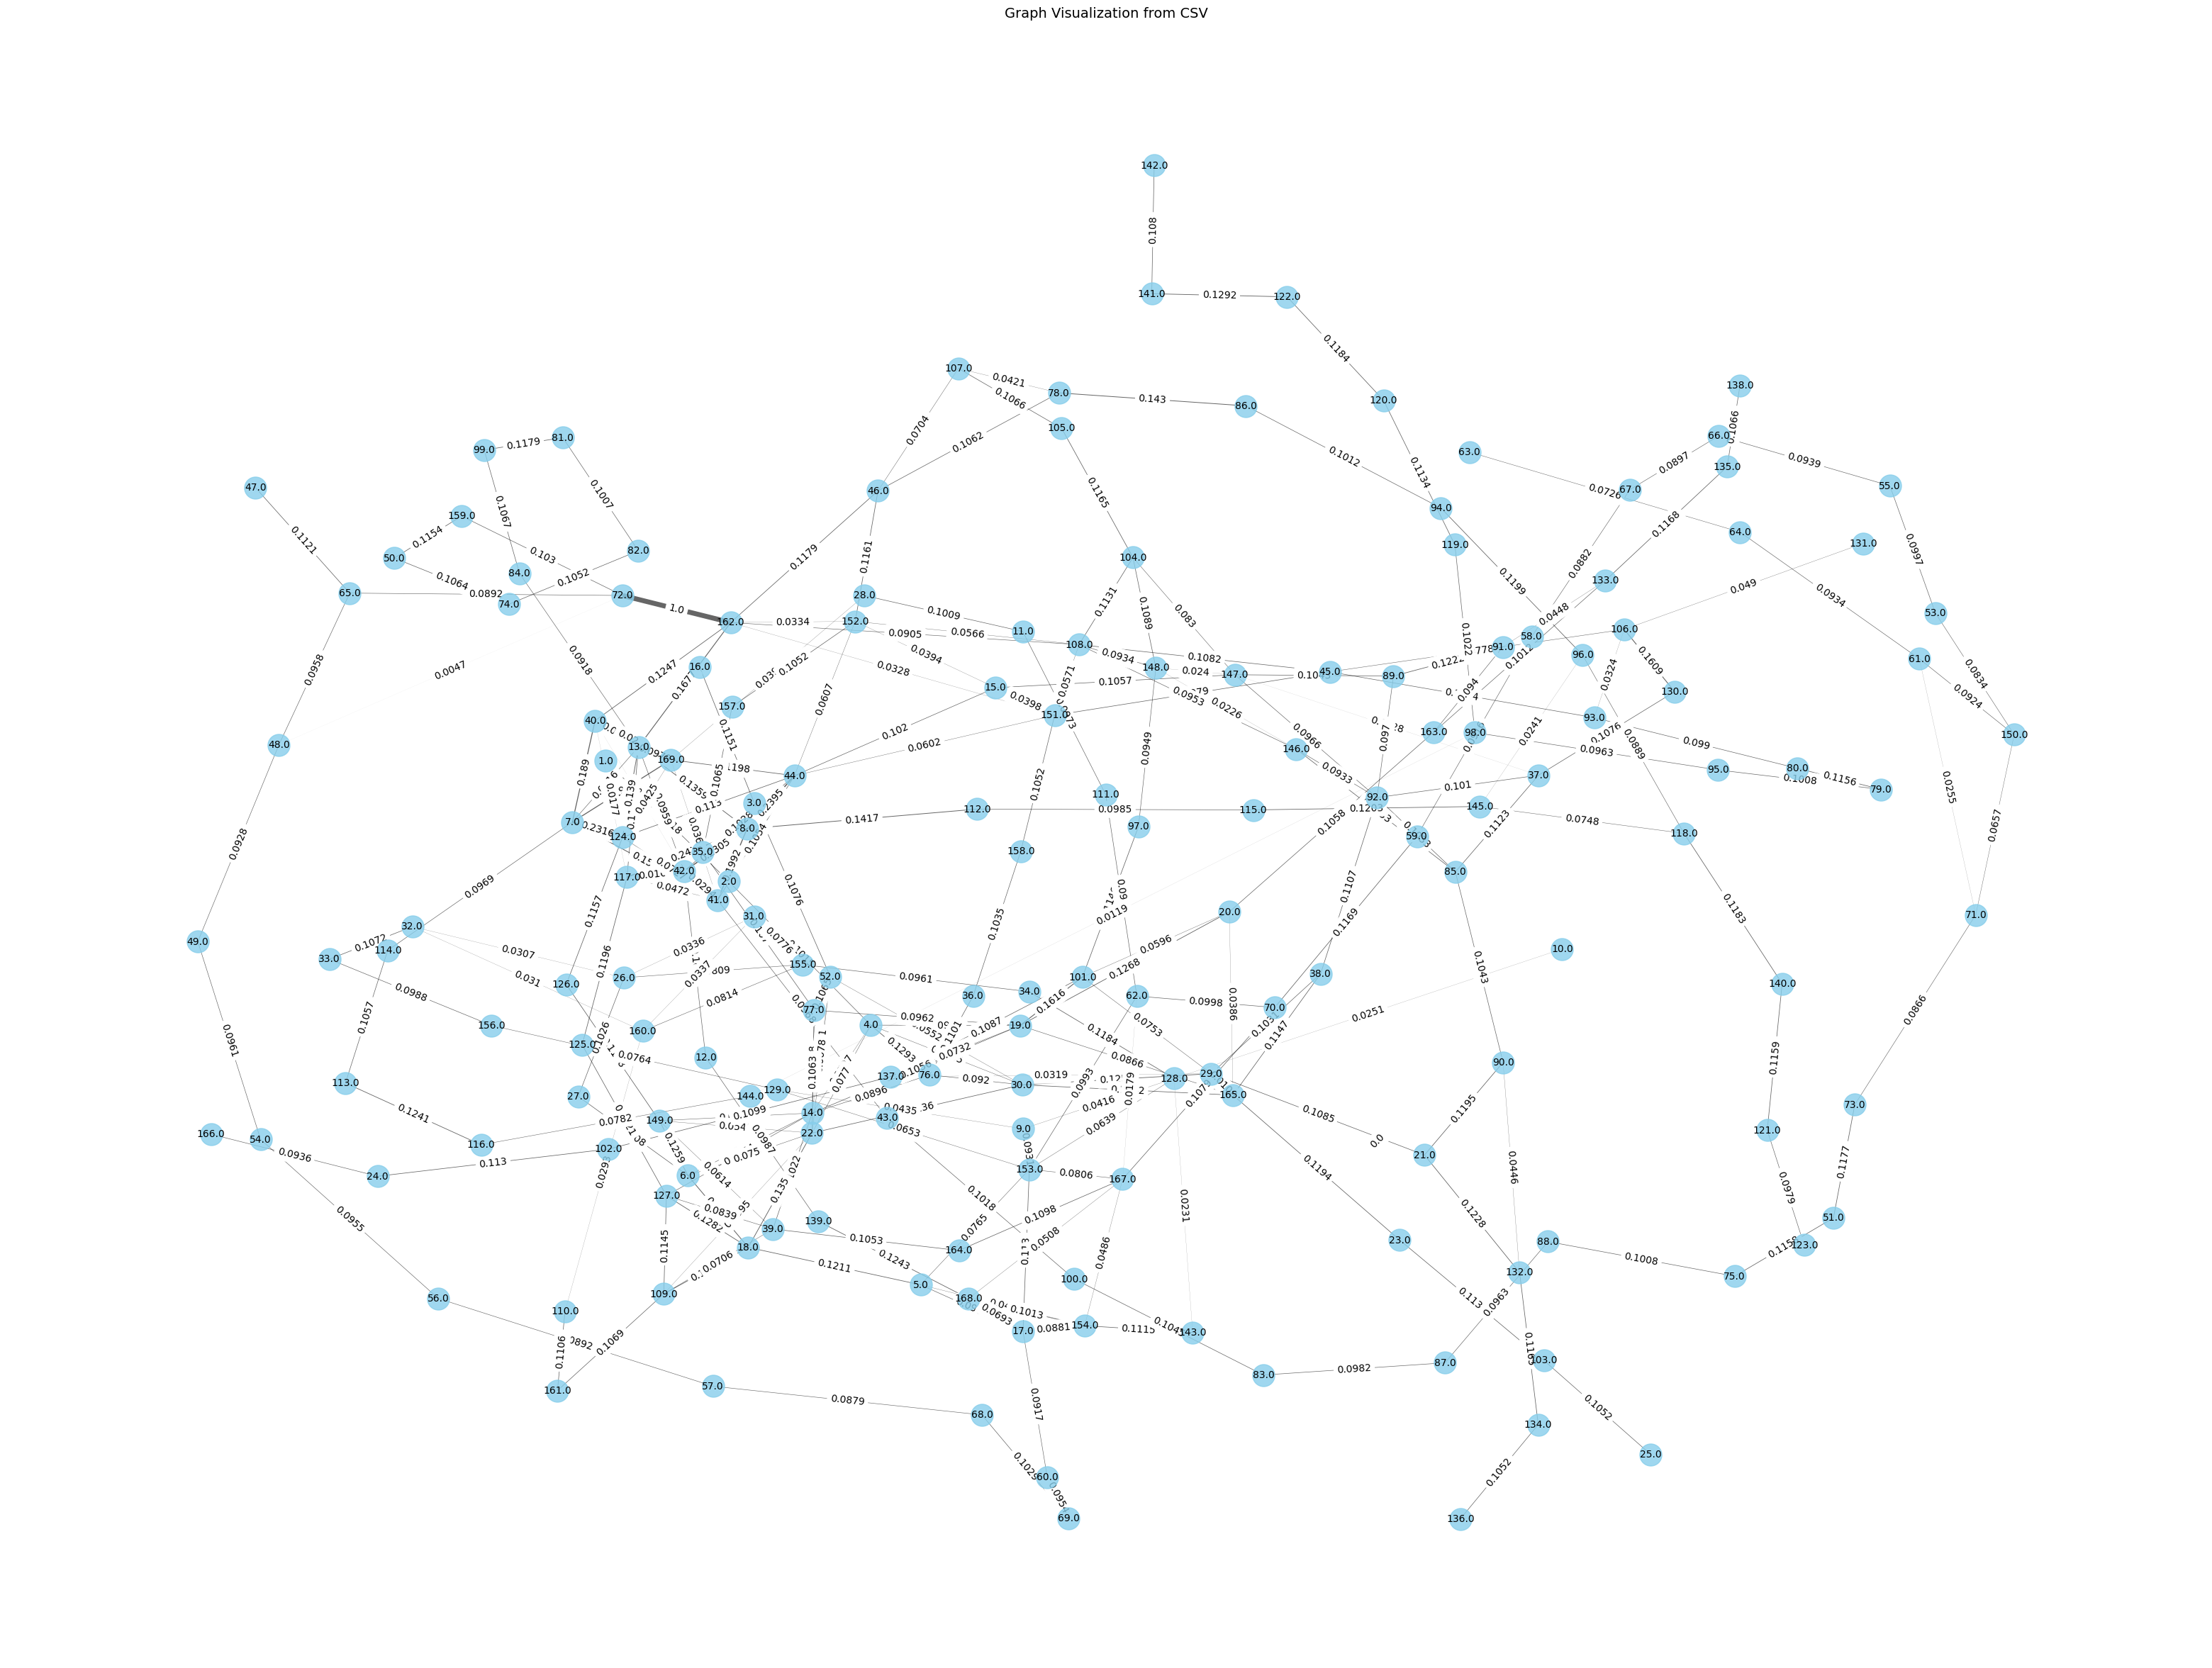

In [8]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Load the CSV
df = pd.read_csv("/Users/lucasastore/Library/Mobile Documents/com~apple~CloudDocs/Doutorado/DCC UFMG/Neural Network Cellular Automata/st_gnca/st_gnca/data/PEMS08/edges_normalized.csv")  # use your original if you didn’t clean yet

# Build a graph
G = nx.Graph()   # use nx.DiGraph() if edges are directed

# Add edges with weight
for _, row in df.iterrows():
    G.add_edge(row["source"], row["target"], weight=row["weight"])

# Draw graph
pos = nx.spring_layout(G, seed=42)  # force-directed layout
plt.figure(figsize=(40, 30))

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=500, node_color="skyblue", alpha=0.8)

# Draw edges (thickness based on weight)
weights = [d["weight"] for _, _, d in G.edges(data=True)]
nx.draw_networkx_edges(G, pos, width=[w / max(weights) * 5 for w in weights], alpha=0.6)

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=10, font_color="black")
nx.draw_networkx_edge_labels(G, pos, edge_labels={(u, v): d["weight"] for u, v, d in G.edges(data=True)})

plt.axis("off")
plt.title("Graph Visualization from CSV", fontsize=14)
plt.show()


In [2]:
pip install pyvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 14.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pyvis]
Note: you may need to restart the kernel to use updated packages.
